In [1]:
import os
import numpy as np
import matplotlib.pylab as plt
import scipy.stats as ss
import scipy.special as ssp
import pymc as pm
import arviz as az
import pytensor.tensor as at
import pytensor.tensor.extra_ops as ate
import corner
import imageio.v2 as imageio
from scipy.stats import gaussian_kde

seed = 123

# Data Generation

$\mathcal{R}_t$ is the rate of 'true' parameter $x_t$ with the unit of per unit time. Now we observe for time $T$ and draw $x_t$ from a Gaussian with mean $\mu_t$ and standard deviation $\sigma_t$:
$$
x_t \sim \mathcal{N}(x_t|\mu_t, \sigma_t)
$$

We add measurement error on $x_t$ by drawing the 'observed' $x_{\rm obs}$ from a Gaussian around $x_t$ with standard deviation $\sigma_{\rm obs}$:
$$
x_{\rm obs} \sim \mathcal{N}(x_{\rm obs}|x, \sigma_{\rm obs})
$$

Then we select $x_{\rm obs}$ which crosses a predefined threshold $a$:
$$
x_{\rm obs}>a
$$

As a result we have $N_{\rm obs}$ observations and of course $N_{\rm obs}<\mathcal{R}_tT$.

In [2]:
Rt = 100
mut = 1.0
sigmat = 1.0
sigmao = 1.5
a = 1.0

In [3]:
def true_param(N, mut, sigmat, seed=seed):
    np.random.seed(seed)
    N1 = np.random.poisson(N)
    xt = np.random.normal(mut, sigmat, N1)
    return xt

def obs_param(xt, sigmao=sigmao, seed=seed):
    np.random.seed(seed)
    xo = np.random.normal(xt, sigmao)
    xo = xo[xo>a]
    return xo

# Inference
The detection probability:
$$
P({\rm det} \mid x) = 1-\Phi\Big(\frac{a-x}{\sigma_{\rm obs}}\Big)
$$
We define $N=\mathcal{R}T$.

The log-likelihood of $N, \mu, \sigma$ is:
$$
\log\mathcal{L}(\vec{x}_{\rm obs} \mid N, \mu, \sigma) = \int_{-\infty}^{\infty}dx (1-\Phi\Big(\frac{x-a}{\sigma_{\rm obs}}\Big)) N.\mathcal{N}(x \mid \mu, \sigma) + \sum_{i=1}^{N_{\rm obs}} \log \int_{-\infty}^{\infty}dx \mathcal{N}(x_{\rm obs}^i \mid x, \sigma_{\rm obs}) N.\mathcal{N}(x \mid \mu, \sigma)
$$

$$
= N \Bigg(1-\Phi\Big(\frac{\mu-a}{\sqrt{\sigma_{\rm obs}^2+\sigma^2}}\Big)\Bigg) + N_{\rm obs}\log N + \sum_{i=1}^{N_{\rm obs}} \log \mathcal{N}(x_{\rm obs}^i \mid \mu, \sqrt{\sigma_{\rm obs}^2+\sigma^2})
$$

and finally,
$$
\mathcal{L}(\vec{x}_{\rm obs} \mid \mathcal{R}, \mu, \sigma) \propto \mathcal{L}(\vec{x}_{\rm obs} \mid N, \mu, \sigma)
$$

In [4]:
sigma = sigmat
def make_model(xo, T, a=a, sigmao=sigmao):
    Nobs = len(xo)

    with pm.Model() as model:
        R = pm.LogNormal('R', np.log(10.0**2.0), 1.0/np.log(10.0**2.0))
        N = R*T
        mu = pm.Uniform('mu', -3, 3)
        #sigma = pm.Uniform('sigma', 0.01, 3)

        _ = pm.Normal('likelihood', mu=mu, sigma=at.sqrt(sigma**2+sigmao**2), observed=xo)

        rv = pm.Normal.dist(0.0, 1.0)
        value = (a-mu)/at.sqrt(sigma**2+sigmao**2)
        rv_logcdf = pm.logcdf(rv, value)
        var = 1-at.exp(rv_logcdf)      
        _ = pm.Potential('sel', -N*var + Nobs*at.log(N))
    return model

# Plotting Functions

In [5]:
def estimate_hpd90_area(R_samps, mu_samps, gridsize=250, pad=0.15):
    samples = np.vstack([R_samps, mu_samps])
    kde = gaussian_kde(samples)

    R_min, R_max = np.min(R_samps), np.max(R_samps)
    mu_min, mu_max = np.min(mu_samps), np.max(mu_samps)

    dR = R_max - R_min
    dmu = mu_max - mu_min

    if dR == 0 or dmu == 0:
        return np.nan

    R_grid = np.linspace(R_min - pad * dR, R_max + pad * dR, gridsize)
    mu_grid = np.linspace(mu_min - pad * dmu, mu_max + pad * dmu, gridsize)

    RR, MM = np.meshgrid(R_grid, mu_grid, indexing="xy")
    pts = np.vstack([RR.ravel(), MM.ravel()])

    pdf = kde(pts).reshape(gridsize, gridsize)

    dA = (R_grid[1] - R_grid[0]) * (mu_grid[1] - mu_grid[0])

    pdf_flat = pdf.ravel()
    order = np.argsort(pdf_flat)[::-1]
    pdf_sorted = pdf_flat[order]

    cumsum = np.cumsum(pdf_sorted) * dA
    cumsum /= cumsum[-1]

    idx90 = np.searchsorted(cumsum, 0.90)
    level90 = pdf_sorted[idx90]

    area90 = np.sum(pdf >= level90) * dA
    return area90

In [6]:
def plot_corner(R_samps, mu_samps, Tval, savepath=None, is_prior=False):
    data = np.vstack([R_samps, mu_samps]).T
    truth = np.array([Rt, mut])

    R_q16, R_q50, R_q84 = np.percentile(R_samps, [16, 50, 84])
    mu_q16, mu_q50, mu_q84 = np.percentile(mu_samps, [16, 50, 84])

    R_mean = np.mean(R_samps)
    mu_mean = np.mean(mu_samps)

    R_sd = np.std(R_samps, ddof=1)
    mu_sd = np.std(mu_samps, ddof=1)

    R_sig = 0.5 * (R_q84 - R_q16)
    mu_sig = 0.5 * (mu_q84 - mu_q16)

    frac_unc_R = R_sig / R_q50 if R_q50 != 0 else np.nan
    frac_unc_mu = mu_sig / np.abs(mu_q50) if mu_q50 != 0 else np.nan

    bias_R = np.abs(R_mean - Rt) / R_sd if R_sd != 0 else np.nan
    bias_mu = np.abs(mu_mean - mut) / mu_sd if mu_sd != 0 else np.nan

    area90 = estimate_hpd90_area(R_samps, mu_samps)

    figure = corner.corner(
        data,
        labels=[r"$R$", r"$\mu$"],
        truths=truth,
        truth_color="r",
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        label_kwargs={"fontsize": 14},
    )

    figure.set_size_inches(8, 8)
    axes = np.array(figure.axes).reshape((2, 2))

    for i in range(2):
        axes[i, i].axvline(truth[i], color="r", lw=1.5)

    ax = axes[1, 0]
    ax.axvline(truth[0], color="r", lw=1.5)
    ax.axhline(truth[1], color="r", lw=1.5)
    ax.plot(truth[0], truth[1], "sr", ms=6)

    header = rf"$T={Tval}$ (prior only)" if is_prior else rf"$T={Tval}$"
    txt = (
        header + "\n"
        + rf"$R = {R_q50:.3g}^{{+{R_q84-R_q50:.3g}}}_{{-{R_q50-R_q16:.3g}}}$" + "\n"
        + rf"$\mu = {mu_q50:.3g}^{{+{mu_q84-mu_q50:.3g}}}_{{-{mu_q50-mu_q16:.3g}}}$" + "\n"
        + rf"$\sigma_R/R \approx {frac_unc_R:.3f}$" + "\n"
        + rf"$\sigma_\mu/|\mu| \approx {frac_unc_mu:.3f}$" + "\n"
        + rf"${{\rm bias}}_R \approx {bias_R:.3f}$" + "\n"
        + rf"${{\rm bias}}_\mu \approx {bias_mu:.3f}$" + "\n"
        + rf"${{\rm area}}_{{90}} \approx {area90:.3g}$"
    )

    figure.text(
        0.58, 0.72,
        txt,
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    title = "Prior only" if is_prior else f"Inference for observing time T = {Tval}"
    figure.suptitle(title, fontsize=16, y=0.98)
    figure.tight_layout()

    if savepath is not None:
        figure.savefig(savepath, dpi=140)
        plt.close(figure)
    else:
        plt.show()

    return {
        "T": Tval,
        "R_mean": R_mean,
        "mu_mean": mu_mean,
        "R_sd": R_sd,
        "mu_sd": mu_sd,
        "R_med": R_q50,
        "R_lo": R_q50 - R_q16,
        "R_hi": R_q84 - R_q50,
        "mu_med": mu_q50,
        "mu_lo": mu_q50 - mu_q16,
        "mu_hi": mu_q84 - mu_q50,
        "frac_unc_R": frac_unc_R,
        "frac_unc_mu": frac_unc_mu,
        "bias_R": bias_R,
        "bias_mu": bias_mu,
        "area90": area90,
    }

# Run
We create an array of observing times $T$ and the expected number of events is $\mathcal{R}_tT$. Then we run the inference.

In [7]:
Nplot = 20
T = 10**4
T_post = np.rint(np.geomspace(10, T, Nplot)).astype(int)
T_post[-1] = int(T)
T_post = np.unique(T_post)

T_grid = np.concatenate(([0], T_post))
print("T values:", T_grid)

T values: [    0    10    14    21    30    43    62    89   127   183   264   379
   546   785  1129  1624  2336  3360  4833  6952 10000]


In [8]:
frame_dir = "corner_frames"
os.makedirs(frame_dir, exist_ok=True)

summaries = []
frame_paths = []


# Prior

Nsamp_prior = 20000
rng_prior = np.random.default_rng(seed)

R_prior = rng_prior.lognormal(
    mean=np.log(10.0**2.0),
    sigma=1.0 / np.log(10.0**2.0),
    size=Nsamp_prior
)
mu_prior = rng_prior.uniform(-3, 3, size=Nsamp_prior)

frame_path = os.path.join(frame_dir, "corner_T_000000.png")
summary0 = plot_corner(
    R_prior, mu_prior, Tval=0, savepath=frame_path, is_prior=True
)

summaries.append(summary0)
frame_paths.append(frame_path)

print(
    f"T=0 (prior) | "
    f"R = {summary0['R_med']:.4g} +{summary0['R_hi']:.4g} -{summary0['R_lo']:.4g} | "
    f"mu = {summary0['mu_med']:.4g} +{summary0['mu_hi']:.4g} -{summary0['mu_lo']:.4g} | "
    f"frac_unc_R = {summary0['frac_unc_R']:.4f} | "
    f"frac_unc_mu = {summary0['frac_unc_mu']:.4f} | "
    f"bias_R = {summary0['bias_R']:.4f} | "
    f"bias_mu = {summary0['bias_mu']:.4f} | "
    f"area90 = {summary0['area90']:.4g}"
)


# Posterior

for i, Tval in enumerate(T_post, start=1):
    xt_sub = true_param(Rt * Tval, mut, sigmat, seed=seed + 2 * i)
    xo_sub = obs_param(xt_sub, sigmao=sigmao, seed=seed + 2 * i + 1)

    with make_model(xo_sub, Tval, a=a, sigmao=sigmao):
        trace = pm.sample(
            draws=1000,
            tune=1000,
            chains=4,
            target_accept=0.9,
            return_inferencedata=True,
            progressbar=True,
        )

    R_samps = np.array(trace.posterior["R"]).ravel()
    mu_samps = np.array(trace.posterior["mu"]).ravel()

    frame_path = os.path.join(frame_dir, f"corner_T_{Tval:06d}.png")
    summary = plot_corner(
        R_samps, mu_samps, Tval=Tval, savepath=frame_path, is_prior=False
    )

    summaries.append(summary)
    frame_paths.append(frame_path)

    print(
        f"T={Tval:6d} | Nobs={len(xo_sub):5d} | "
        f"R = {summary['R_med']:.4g} +{summary['R_hi']:.4g} -{summary['R_lo']:.4g} | "
        f"mu = {summary['mu_med']:.4g} +{summary['mu_hi']:.4g} -{summary['mu_lo']:.4g} | "
        f"frac_unc_R = {summary['frac_unc_R']:.4f} | "
        f"frac_unc_mu = {summary['frac_unc_mu']:.4f} | "
        f"bias_R = {summary['bias_R']:.4f} | "
        f"bias_mu = {summary['bias_mu']:.4f} | "
        f"area90 = {summary['area90']:.4g}"
    )

T=0 (prior) | R = 100 +24.23 -19.35 | mu = -0.003006 +2.028 -2.04 | frac_unc_R = 0.2178 | frac_unc_mu = 676.4876 | bias_R = 0.1112 | bias_mu = 0.5778 | area90 = 489.6


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [R, mu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


T=    10 | Nobs=  529 | R = 104.2 +7.105 -6.64 | mu = 1.028 +0.1251 -0.1245 | frac_unc_R = 0.0660 | frac_unc_mu = 0.1215 | bias_R = 0.6394 | bias_mu = 0.2107 | area90 = 8.74


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [R, mu]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 36 seconds.


T=  6952 | Nobs=348315 | R = 100.2 +0.2704 -0.2795 | mu = 1 +0.00466 -0.005102 | frac_unc_R = 0.0027 | frac_unc_mu = 0.0049 | bias_R = 0.7483 | bias_mu = 0.0065 | area90 = 0.01258


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [R, mu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 55 seconds.


T= 10000 | Nobs=500247 | R = 100.1 +0.2335 -0.2334 | mu = 0.9995 +0.00424 -0.004094 | frac_unc_R = 0.0023 | frac_unc_mu = 0.0042 | bias_R = 0.3019 | bias_mu = 0.1090 | area90 = 0.009184


In [9]:
T_vals = np.array([s["T"] for s in summaries])
fracR = np.array([s["frac_unc_R"] for s in summaries])
fracmu = np.array([s["frac_unc_mu"] for s in summaries])
biasR = np.array([s["bias_R"] for s in summaries])
biasmu = np.array([s["bias_mu"] for s in summaries])
area90 = np.array([s["area90"] for s in summaries])

# Does fractional uncertainty decrease with $T$?

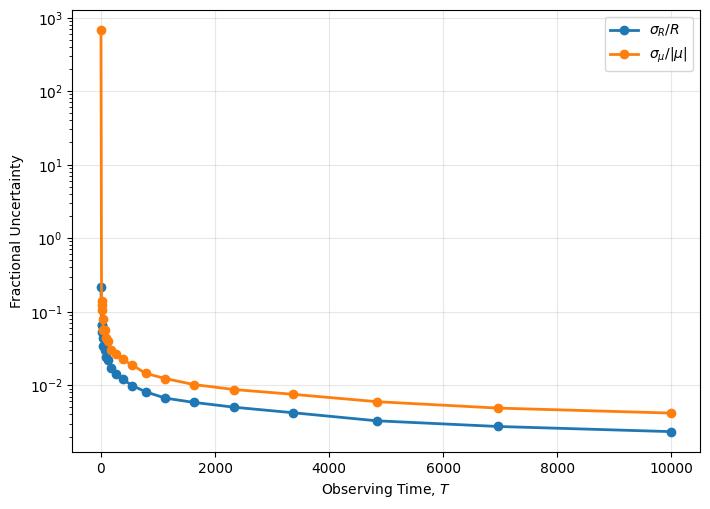

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(T_vals, fracR, marker="o", lw=2, label=r"$\sigma_R/R$")
ax.plot(T_vals, fracmu, marker="o", lw=2, label=r"$\sigma_\mu/|\mu|$")

ax.set_yscale("log")
ax.set_xlabel(r"Observing Time, $T$")
ax.set_ylabel("Fractional Uncertainty")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Yes!

# Is the bias always less than $3\sigma$?

$$
{\rm bias} = \frac{\langle {\rm param} \rangle - {\rm param}_t}{\sigma}
$$

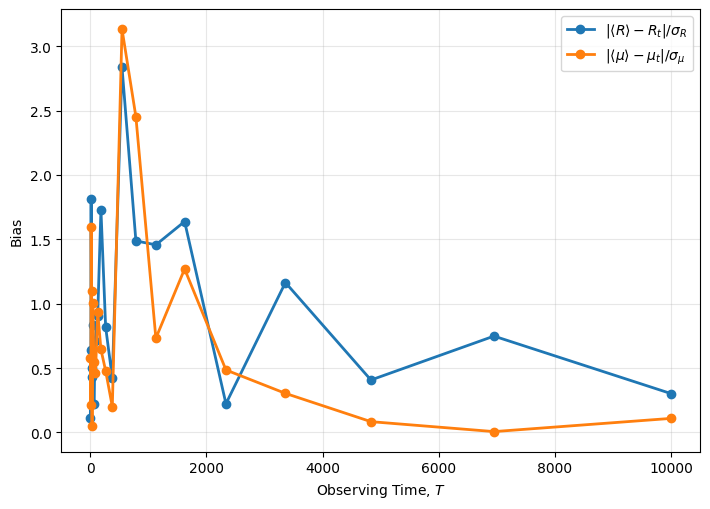

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(T_vals, biasR, marker="o", lw=2, label=r"$|\langle R\rangle - R_t|/\sigma_R$")
ax.plot(T_vals, biasmu, marker="o", lw=2, label=r"$|\langle \mu\rangle - \mu_t|/\sigma_\mu$")

ax.set_xlabel(r"Observing Time, $T$")
ax.set_ylabel("Bias")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Yes!

# Most importantly, does the volume of $90\%$ confidence interval decrease with $T$?

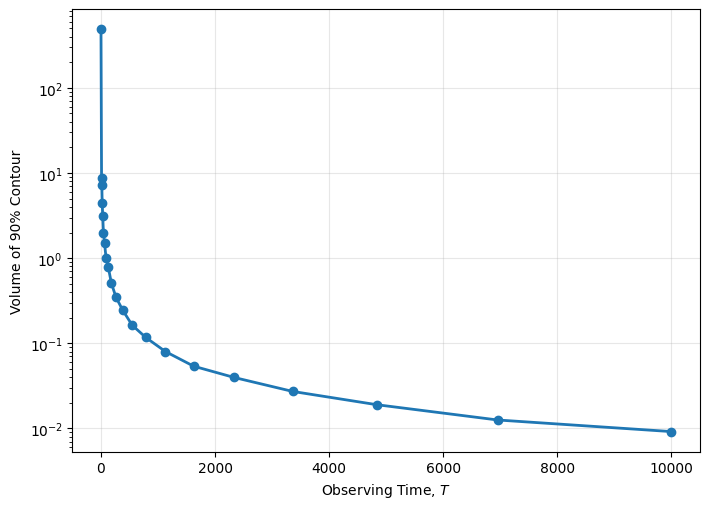

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(T_vals, area90, marker="o", lw=2)

ax.set_yscale("log")
ax.set_xlabel(r"Observing Time, $T$")
ax.set_ylabel(r"Volume of 90% Contour")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Yes!

# Make gif from corners

In [17]:
gif_path = "corner_evolution.gif"
images = [imageio.imread(fp) for fp in frame_paths]
imageio.mimsave(gif_path, images, duration=1.0, loop=0)

print(f"\nSaved animation to: {gif_path}")


Saved animation to: corner_evolution.gif


# Hence we've showed that inhomogeneous Poisson likelihood is sufficient to model the Poisson noise.

### Explanation

We've showed even with a relatively small number of observations, population inference remains **unbiased**. In other words, the true population parameters are correctly recovered, but with larger uncertainties when the number of observations is small.

This naturally leads to another question: why do some population trends reported in successive gravitational-wave transient catalogs sometimes change or weaken? For example:

- unequal-mass binaries favor higher effective spin (in terms of central tendency wise), or  
- the merger rate drops on the left side of the 35 Msun  

appears less significant in later catalogs.

The reason is that the **true population model of compact binary mergers is unknown**. As new data become available, we modify the population model and the hyperpriors to better capture features suggested by the data. This happens in both **strongly parameterized models** and **weakly parameterized models**. Explictly:

- in parametric model, the functional form of the population of mass, spin and redshift may change or the prior on the hyperparameters are updated,
- in 'non-parametric' approaches, choices such as bin sizes, Gaussian process kernels, or hyperpriors (or hyperhyperprior) are updated.

However, if the population model and priors were kept exactly the same between the *n*-th and *(n+1)*-th gravitational-wave catalogs, the allowed region of the hyperparameter space (remember the integrate merger rate is also a hyperparameter) in the *(n+1)* analysis would simply be a **subset of the region allowed by the n-th analysis**.